<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_B/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction**

In this experiment, we aim to explore and compare two fundamental supervised machine learning algorithms — Support Vector Machine (SVM) and Decision Tree Classifier — for a binary classification task.
We use the Social Network Ads dataset, which predicts whether a user purchases a product based on their Age and Estimated Salary.


The goal is to:

Preprocess and visualize the dataset.

Train and evaluate SVM (Linear & RBF) and Decision Tree models.

Compare their performance using accuracy, precision, recall, F1-score, and decision boundaries.

SVM works by finding the optimal hyperplane that separates two classes with the maximum margin, while Decision Trees split data into branches using rules derived from feature thresholds.

This module imports all necessary libraries for data processing, visualization, and model development.

Pandas, NumPy: Handle data manipulation and numerical operations.

Matplotlib, Seaborn: Create visualizations for better understanding.

Scikit-learn: Provides models like SVM, Decision Tree, and performance metrics.

Setting a consistent visualization style using Seaborn ensures that all plots have a clean and professional appearance.

In [ ]:
# MODULE 1: IMPORTS & SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)

sns.set(style="whitegrid")
print("All libraries imported successfully.")


All libraries imported successfully.


This module focuses on loading the dataset and performing Exploratory Data Analysis (EDA).

The dataset is uploaded and read into a DataFrame.

Target distribution shows how balanced or imbalanced the dataset is.

Visualization:

Countplot: Displays how many users purchased or not purchased.

Scatterplot: Shows how age and salary relate to purchase decisions.

Through EDA, we gain insights into the data distribution and relationships among features, which guides preprocessing and model selection.

Saving Social_Network_Ads.csv to Social_Network_Ads (3).csv
Uploaded file: Social_Network_Ads (3).csv

Dataset Head:
   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB
None

Target Distribution:
Purchased
0    257
1    143
Name: count, dtype: int64


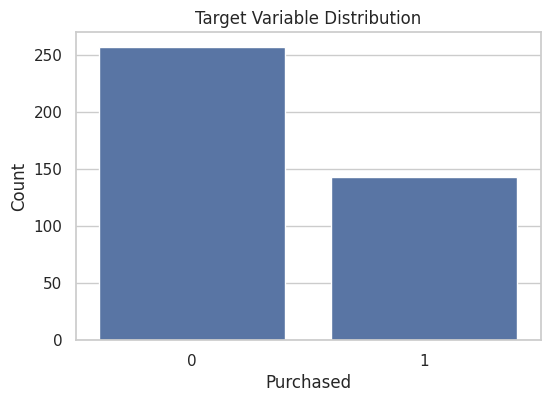

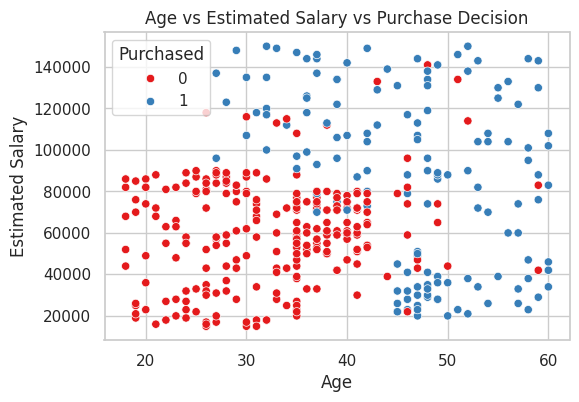

In [ ]:
# MODULE 2: DATA LOADING & EXPLORATION

# Upload dataset from your local system
from google.colab import files
uploaded = files.upload()

import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Automatically detect the uploaded file name
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

# Read CSV file into a DataFrame
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Display dataset information
print("\nDataset Head:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nTarget Distribution:")
print(df['Purchased'].value_counts())

# Basic visualizations
plt.figure(figsize=(6,4))
sns.countplot(x='Purchased', data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Purchased")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='Age', y='EstimatedSalary', hue='Purchased', data=df, palette='Set1')
plt.title("Age vs Estimated Salary vs Purchase Decision")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()


Data preprocessing ensures the model receives clean, properly formatted input.

Steps involved:

Feature Selection: Only relevant columns — Age and EstimatedSalary — are used as predictors.

Target Extraction: The “Purchased” column acts as the binary label.

Train-Test Split: The dataset is split (75% training, 25% testing) using stratification to maintain class balance.

Feature Scaling:

StandardScaler standardizes features to have zero mean and unit variance.

Crucial for SVM, which is a distance-based algorithm — unscaled features can bias the model.

In [ ]:
# ===================================================================
# MODULE 3: DATA PREPROCESSING
# ===================================================================

X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\n Data preprocessing complete!")
print(f"Training samples: {X_train_s.shape[0]}")
print(f"Testing samples: {X_test_s.shape[0]}")

# Quick preview after scaling
print("\nScaled feature sample:\n", X_train_s[:5])



 Data preprocessing complete!
Training samples: 300
Testing samples: 100

Scaled feature sample:
 [[ 0.45809581  0.54309037]
 [ 0.17532062  0.71372445]
 [-0.57874655  1.33938275]
 [-0.57874655 -1.04949441]
 [ 0.83512939  0.23026122]]


This module trains three different classification models:

SVM (Linear Kernel):

Attempts to separate data using a straight hyperplane.

Works well when classes are linearly separable.

SVM (RBF Kernel):

Uses a non-linear kernel (Radial Basis Function) to map data into higher dimensions, allowing curved decision boundaries.

Decision Tree Classifier:

Splits the data based on feature thresholds using metrics like Gini impurity or information gain.

Creates a tree-like structure for decision-making.

Each model is trained on the preprocessed (scaled) data and stored for later evaluation.

In [ ]:
# ===================================================================
# MODULE 4: MODEL TRAINING
# ===================================================================

models = {
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    print(f" Model '{name}' trained successfully!")

print("\n Models trained:", list(models.keys()))

 Model 'SVM (Linear)' trained successfully!
 Model 'SVM (RBF)' trained successfully!
 Model 'Decision Tree' trained successfully!

 Models trained: ['SVM (Linear)', 'SVM (RBF)', 'Decision Tree']


Evaluation involves testing each trained model on unseen data (test set) and calculating performance metrics.

Metrics used:

Accuracy: Percentage of correct predictions.

Precision: How many predicted positives are actual positives.

Recall: How many actual positives were identified correctly.

F1-Score: Harmonic mean of precision and recall.

Confusion Matrix: Shows correct vs. incorrect predictions in tabular form.

For SVMs, additional plots are generated:

ROC Curve (AUC): Trade-off between sensitivity and specificity.

Precision-Recall Curve: Balances positive prediction quality.

Learning Curve: Shows model performance as training data increases.

Validation Curve: Evaluates how tuning hyperparameter C affects performance.


================== SVM (Linear) ==================
Accuracy : 0.8200
Precision: 0.8462
Recall   : 0.6111
F1-Score : 0.7097

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.94      0.87        64
           1       0.85      0.61      0.71        36

    accuracy                           0.82       100
   macro avg       0.83      0.77      0.79       100
weighted avg       0.82      0.82      0.81       100



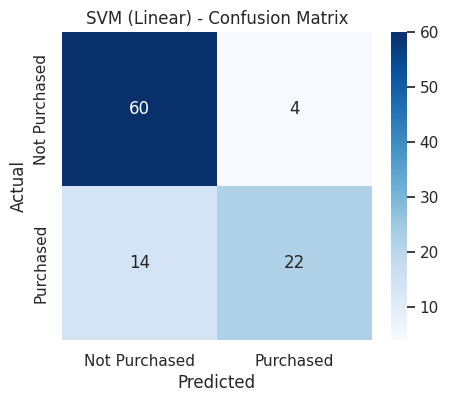

Generating advanced SVM plots...


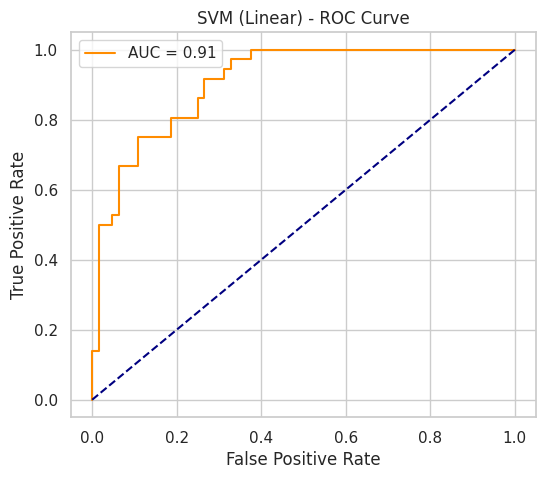

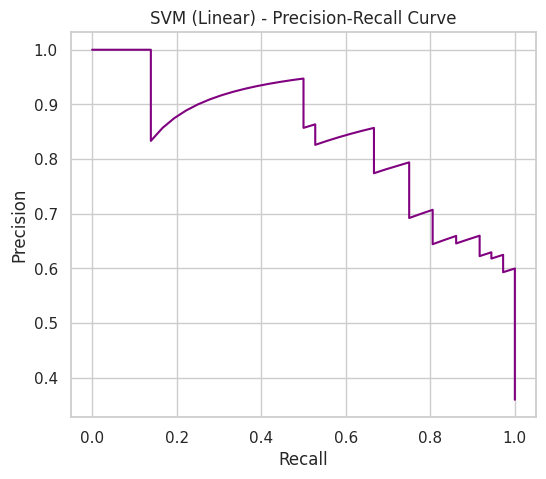

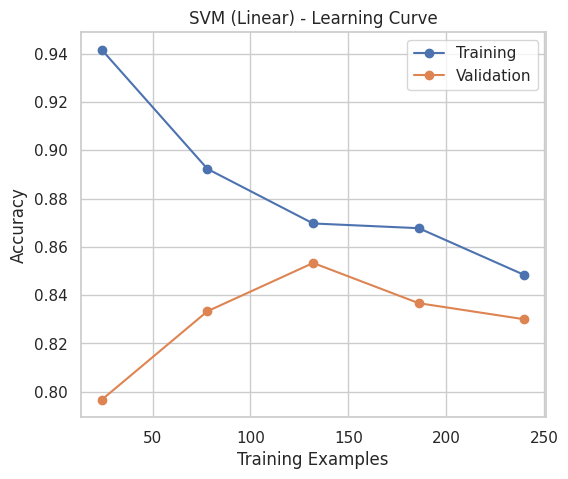

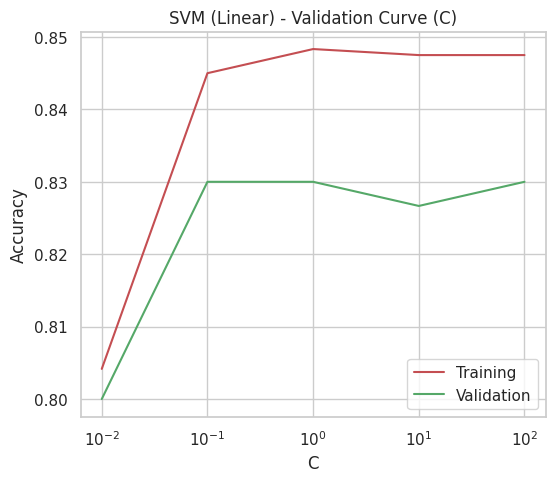


================== SVM (RBF) ==================
Accuracy : 0.9100
Precision: 0.8649
Recall   : 0.8889
F1-Score : 0.8767

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        64
           1       0.86      0.89      0.88        36

    accuracy                           0.91       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.91      0.91      0.91       100



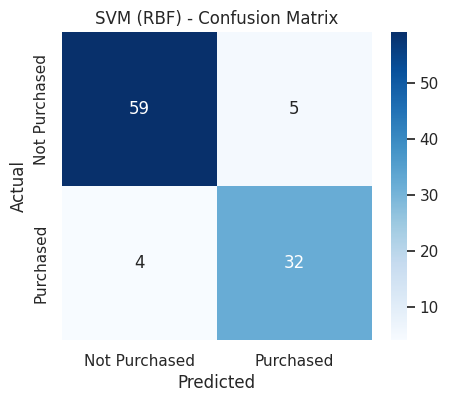

Generating advanced SVM plots...


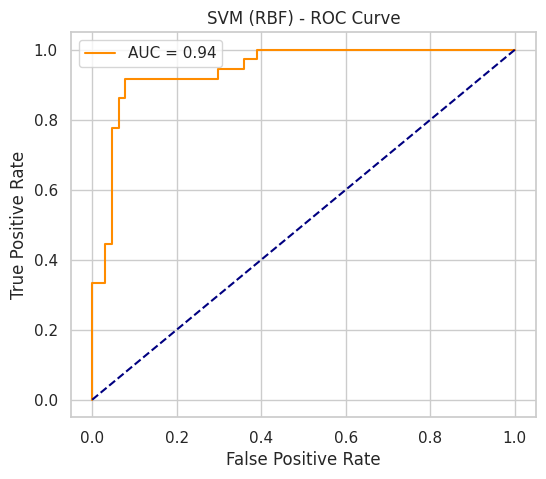

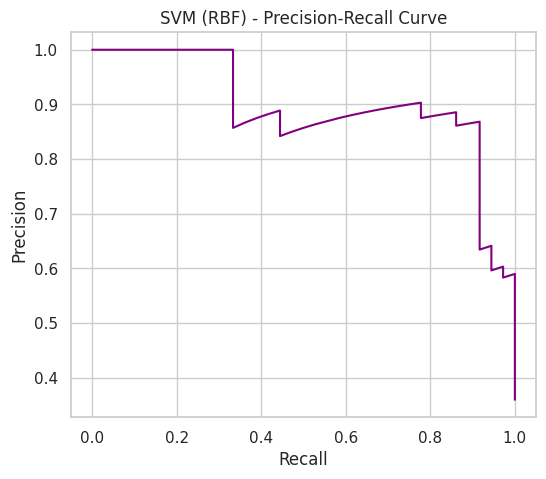

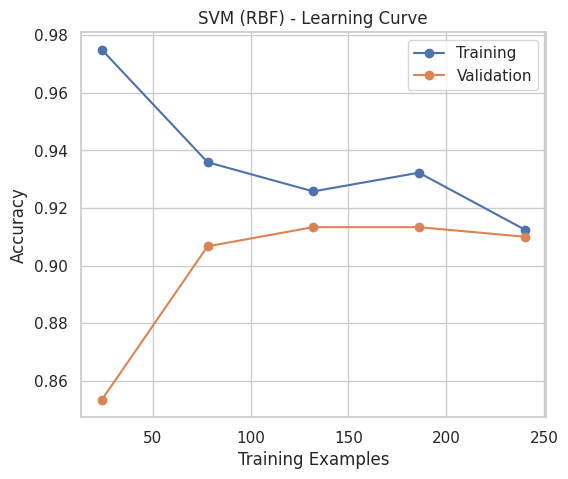

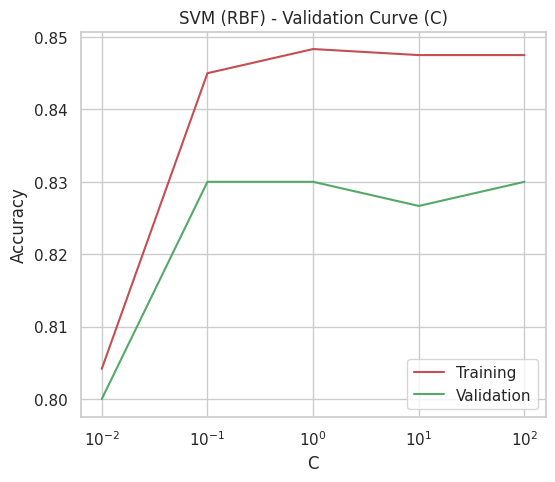


================== Decision Tree ==================
Accuracy : 0.8900
Precision: 0.8378
Recall   : 0.8611
F1-Score : 0.8493

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.84      0.86      0.85        36

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



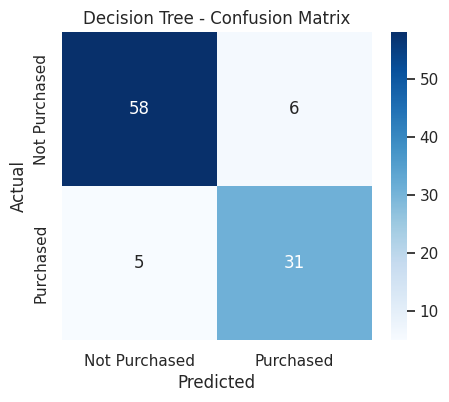

In [ ]:
# ===================================================================
# MODULE 5: MODEL EVALUATION & VISUALIZATION
# ===================================================================

for name, model in models.items():
    print(f"\n================== {name} ==================")
    y_pred = model.predict(X_test_s)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Purchased','Purchased'],
                yticklabels=['Not Purchased','Purchased'])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Extra visualizations only for SVMs
    if "SVM" in name:
        print("Generating advanced SVM plots...")

        # ROC Curve
        y_score = model.decision_function(X_test_s)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
        plt.plot([0,1],[0,1],'--',color='navy')
        plt.title(f"{name} - ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision, color='purple')
        plt.title(f"{name} - Precision-Recall Curve")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.show()

        # Learning Curve
        train_sizes, train_scores, test_scores = learning_curve(model, X_train_s, y_train, cv=5)
        plt.figure(figsize=(6,5))
        plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training')
        plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Validation')
        plt.title(f"{name} - Learning Curve")
        plt.xlabel("Training Examples")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

        # Validation Curve for C
        param_range = [0.01, 0.1, 1, 10, 100]
        train_scores, test_scores = validation_curve(
            SVC(kernel='linear'), X_train_s, y_train,
            param_name="C", param_range=param_range, cv=5
        )
        plt.figure(figsize=(6,5))
        plt.semilogx(param_range, np.mean(train_scores, axis=1), label="Training", color="r")
        plt.semilogx(param_range, np.mean(test_scores, axis=1), label="Validation", color="g")
        plt.title(f"{name} - Validation Curve (C)")
        plt.xlabel("C")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()


Decision Boundaries:

Visualize how each model divides the feature space into distinct classes.

Helps interpret how models make decisions based on Age and Salary.

Performance Summary:

Metrics (Accuracy, Precision, Recall, F1-score) are compiled into a table.

A comparative bar plot illustrates which model performs best across different criteria.

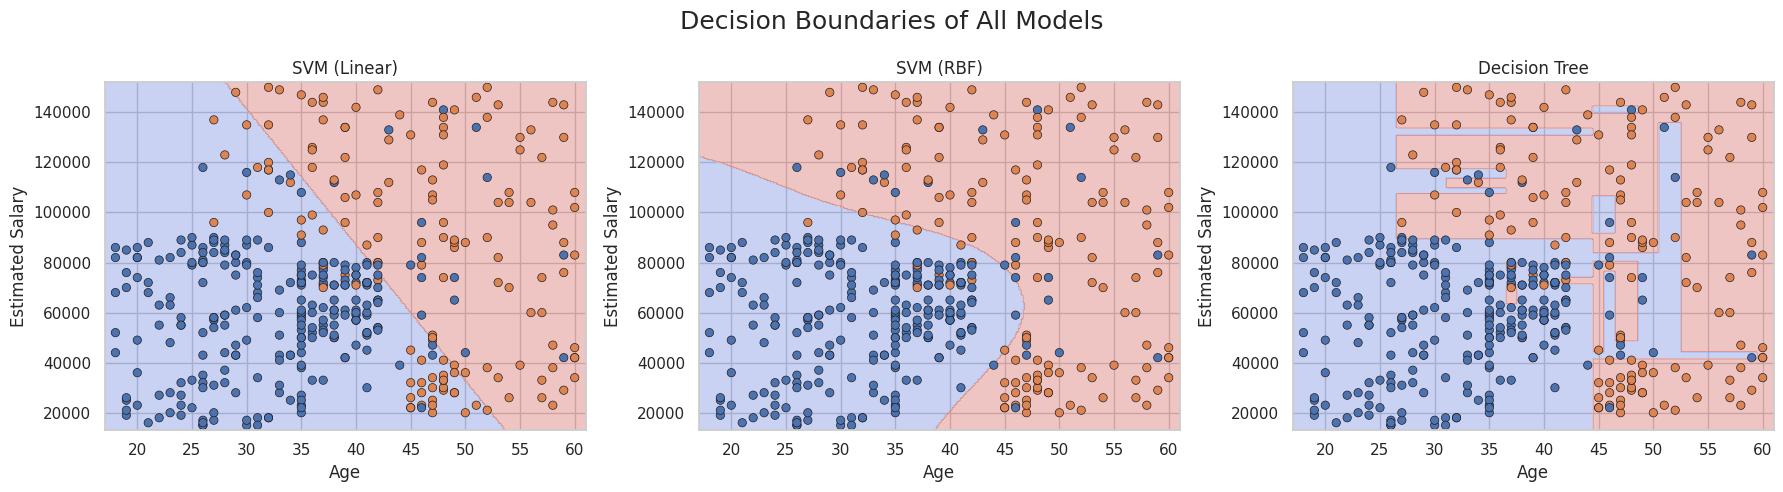


🏁 Final Performance Summary:

           Model  Accuracy  Precision    Recall  F1-Score
0   SVM (Linear)      0.82   0.846154  0.611111  0.709677
1      SVM (RBF)      0.91   0.864865  0.888889  0.876712
2  Decision Tree      0.89   0.837838  0.861111  0.849315


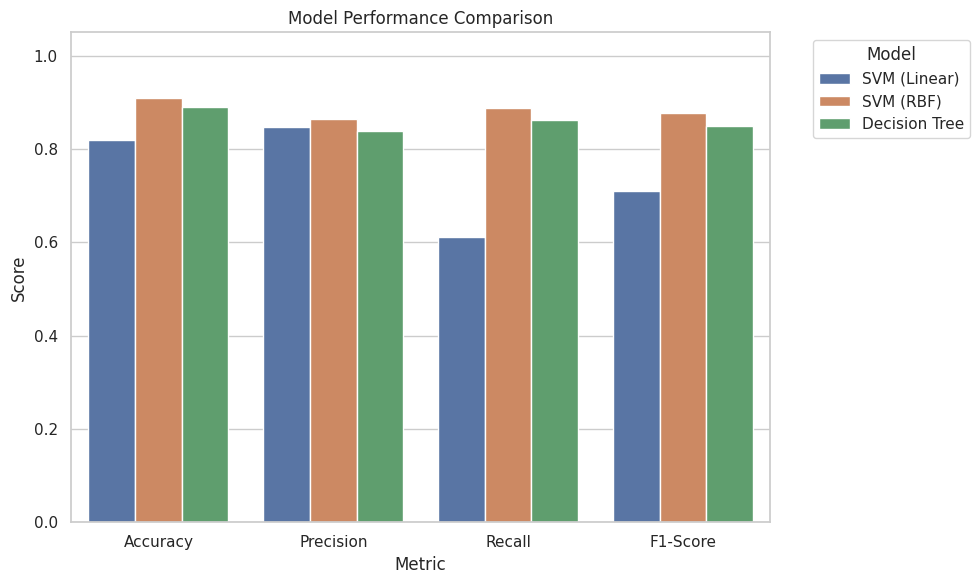

In [ ]:
# ===================================================================
# MODULE 6: DECISION BOUNDARIES & PERFORMANCE SUMMARY
# ===================================================================

# ---- Decision Boundaries ----
X_orig = df[['Age','EstimatedSalary']].values
y_orig = df['Purchased'].values

fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    x_min, x_max = X_orig[:,0].min()-1, X_orig[:,0].max()+1
    y_min, y_max = X_orig[:,1].min()-2000, X_orig[:,1].max()+2000
    xx, yy = np.meshgrid(np.linspace(x_min,x_max,300),
                         np.linspace(y_min,y_max,300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(scaler.transform(grid)).reshape(xx.shape)
    axes[i].contourf(xx,yy,Z,alpha=0.3,cmap='coolwarm')
    sns.scatterplot(x=X_orig[:,0], y=X_orig[:,1], hue=y_orig,
                    palette='deep', edgecolor='k', ax=axes[i], legend=False)
    axes[i].set_title(name)
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Estimated Salary")

plt.suptitle("Decision Boundaries of All Models", fontsize=18)
plt.tight_layout()
plt.show()

# ---- Performance Summary Table ----
metrics_summary = []
for name, model in models.items():
    y_pred = model.predict(X_test_s)
    metrics_summary.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

summary_df = pd.DataFrame(metrics_summary,
    columns=["Model","Accuracy","Precision","Recall","F1-Score"])
print("\n🏁 Final Performance Summary:\n")
print(summary_df)

# ---- Visualize Summary ----
summary_melted = summary_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(x="Metric", y="Score", hue="Model", data=summary_melted)
plt.title("Model Performance Comparison")
plt.ylim(0,1.05)
plt.legend(title="Model", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()


| Feature                  | Support Vector Machine (SVM)      | Decision Tree               |
| ------------------------ | --------------------------------- | --------------------------- |
| **Model Type**           | Margin-based classifier           | Rule-based classifier       |
| **Boundary Type**        | Linear / Non-linear (via kernels) | Piecewise linear            |
| **Interpretability**     | Harder to interpret               | Easy to interpret           |
| **Overfitting**          | Less prone with regularization    | Prone without pruning       |
| **Computation**          | Expensive for large datasets      | Fast for small datasets     |
| **Performance on Noise** | Sensitive to overlapping data     | Handles noise moderately    |
| **Scaling Needed**       | Yes                               | No                          |
| **Use Case**             | High-dimensional data             | Simple rule-based decisions |


Conclusions:

SVM (RBF) often performs better when the relationship between features and target is non-linear.

Decision Tree offers interpretability and simple rule-based decisions but may overfit without pruning.

SVM provides better generalization but requires careful tuning and scaling.